In [1]:
from hydra import initialize, compose
from hydra.utils import instantiate

import numpy as np

from scipy.stats import spearmanr, kendalltau

from einops import rearrange

import torch

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

import pytorch_lightning as pl
from pytorch_lightning.utilities import move_data_to_device

from bliss.global_env import GlobalEnv

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
ckpt = "/data/scratch/twhit/checkpoints/trained_encoder_dc2.ckpt"

with initialize(config_path="../", version_base=None):
    cfg = compose("config_dc2", {
        "train.pretrained_weights=" + ckpt,
        })

seed = pl.seed_everything(cfg.train.seed)
GlobalEnv.seed_in_this_program = seed

Seed set to 123123


**Configure the test dataloader:**

In [3]:
data_source = instantiate(cfg.train.data_source)
data_source.setup("test")
test_dl = data_source.test_dataloader()

**Load encoder weights:**

In [4]:
encoder = instantiate(cfg.encoder).to(device)
encoder_state_dict = torch.load(cfg.train.pretrained_weights, map_location=device)["state_dict"]
encoder.load_state_dict(encoder_state_dict)
encoder = encoder.eval()

**Store shear and convergence maps for the test images:**

In [5]:
num_tiles_per_side = 8
num_bins = 4
shear1_true = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins, device=device)
shear1_pred = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins, device=device)
shear1_std = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins, device=device)
shear2_true = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins, device=device)
shear2_pred = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins, device=device)
shear2_std = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins, device=device)
convergence_true = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins, device=device)
convergence_pred = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins, device=device)
convergence_std = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins, device=device)

ra = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins, device=device)
dec = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins, device=device)
test_loss = torch.zeros(len(test_dl), device = device)

num_samples = 3
convergence_pred_samples = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins, num_samples, device=device)
shear1_pred_samples = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins, num_samples, device=device)
shear2_pred_samples = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins, num_samples, device=device)

i = -1
for b in test_dl:
    i += 1
    print(i)
    batch = move_data_to_device(b, device)
    
    shear1_true[i] = batch['tile_catalog']['shear_1'].squeeze()
    shear2_true[i] = batch['tile_catalog']['shear_2'].squeeze()
    convergence_true[i] = batch['tile_catalog']['convergence'].squeeze()
    ra[i] = batch['tile_catalog']['ra'].squeeze()
    dec[i] = batch['tile_catalog']['dec'].squeeze()
    
    with torch.no_grad():
        input_lst = [inorm.get_input_tensor(batch) for inorm in encoder.image_normalizers]
        inputs = torch.cat(input_lst, dim=2)

        x_cat_marginal = encoder.net(inputs).squeeze(0)
        shear1_pred[i] = x_cat_marginal[:,:,0:num_bins].squeeze()
        shear1_std[i] = x_cat_marginal[:,:,num_bins:(2*num_bins)].exp().sqrt().squeeze()
        shear2_pred[i] = x_cat_marginal[:,:,(2*num_bins):(3*num_bins)].squeeze()
        shear2_std[i] = x_cat_marginal[:,:,(3*num_bins):(4*num_bins)].exp().sqrt().squeeze()
        convergence_pred[i] = x_cat_marginal[:,:,(4*num_bins):(5*num_bins)].squeeze()
        convergence_std[i] = x_cat_marginal[:,:,(5*num_bins):(6*num_bins)].exp().sqrt().squeeze()
        for j in range(num_samples):
            sample_cat = encoder.sample(batch, use_mode=False)
            convergence_pred_samples[i,...,j] = sample_cat['convergence'].squeeze()
            shear1_pred_samples[i,...,j] = sample_cat['shear_1'].squeeze()
            shear2_pred_samples[i,...,j] = sample_cat['shear_2'].squeeze()
        test_loss[i] = encoder._compute_loss(batch, None)

0


/home/twhit/bliss/.venv/lib/python3.12/site-packages/pytorch_lightning/core/module.py:441: You are trying to `self.log()` but the `self.trainer` reference is not registered on the model yet. This is most likely because the model hasn't been passed to the `Trainer`


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39


**Compute test RMSEs:**

In [6]:
for b in range(num_bins):
    print(f'redshift bin {b}')
    print(f'shear 1 test RMSE = {((shear1_true[...,b] - shear1_pred[...,b]) ** 2).mean().sqrt()}')
    print(f'shear 2 test RMSE = {((shear2_true[...,b] - shear2_pred[...,b]) ** 2).mean().sqrt()}')
    print(f'convergence test RMSE = {((convergence_true[...,b] - convergence_pred[...,b]) ** 2).mean().sqrt()}\n')

redshift bin 0
shear 1 test RMSE = 0.004616943653672934
shear 2 test RMSE = 0.005078419111669064
convergence test RMSE = 0.004290521144866943

redshift bin 1
shear 1 test RMSE = 0.009011026471853256
shear 2 test RMSE = 0.007531832903623581
convergence test RMSE = 0.008021598681807518

redshift bin 2
shear 1 test RMSE = 0.011511271819472313
shear 2 test RMSE = 0.010105788707733154
convergence test RMSE = 0.010261960327625275

redshift bin 3
shear 1 test RMSE = 0.014725922606885433
shear 2 test RMSE = 0.014634164981544018
convergence test RMSE = 0.015888851135969162



**Compute Pearson correlation coefficients:**

In [7]:
for b in range(num_bins):
    print(f'redshift bin {b}')
    print(f'shear 1 pearson correlation = {np.corrcoef(shear1_true[...,b].flatten().cpu(), shear1_pred[...,b].flatten().cpu())[1,0]}')
    print(f'shear 2 pearson correlation = {np.corrcoef(shear2_true[...,b].flatten().cpu(), shear2_pred[...,b].flatten().cpu())[1,0]}')
    print(f'convergence pearson correlation = {np.corrcoef(convergence_true[...,b].flatten().cpu(), convergence_pred[...,b].flatten().cpu())[1,0]}\n')

redshift bin 0
shear 1 pearson correlation = 0.24939223223113471
shear 2 pearson correlation = 0.29516864551815214
convergence pearson correlation = 0.6151824389867699

redshift bin 1
shear 1 pearson correlation = 0.31359388269249766
shear 2 pearson correlation = 0.37671760012376315
convergence pearson correlation = 0.7106147772919522

redshift bin 2
shear 1 pearson correlation = 0.3672525883810883
shear 2 pearson correlation = 0.4005987112044185
convergence pearson correlation = 0.7400306066946728

redshift bin 3
shear 1 pearson correlation = 0.3425285268061512
shear 2 pearson correlation = 0.3696125549133036
convergence pearson correlation = 0.6922921291783966



**Compute Spearman correlation coefficients:**

In [8]:
for b in range(num_bins):
    print(f'redshift bin {b}')
    print(f'shear 1 spearman correlation = {spearmanr(shear1_true[...,b].flatten().cpu(), shear1_pred[...,b].flatten().cpu())[0]}')
    print(f'shear 2 spearman correlation = {spearmanr(shear2_true[...,b].flatten().cpu(), shear2_pred[...,b].flatten().cpu())[0]}')
    print(f'convergence spearman correlation = {spearmanr(convergence_true[...,b].flatten().cpu(), convergence_pred[...,b].flatten().cpu())[0]}\n')

redshift bin 0
shear 1 spearman correlation = 0.2638839587246834
shear 2 spearman correlation = 0.27584151432526094
convergence spearman correlation = 0.5578074126332467

redshift bin 1
shear 1 spearman correlation = 0.29981662957228244
shear 2 spearman correlation = 0.33476282942329105
convergence spearman correlation = 0.6646620930152503

redshift bin 2
shear 1 spearman correlation = 0.35987336393803665
shear 2 spearman correlation = 0.3504238865884677
convergence spearman correlation = 0.6980403049634281

redshift bin 3
shear 1 spearman correlation = 0.33779023312707745
shear 2 spearman correlation = 0.3194416003040758
convergence spearman correlation = 0.6330032654750017



**Compute Kendall correlation coefficients:**

In [9]:
for b in range(num_bins):
    print(f'redshift bin {b}')
    print(f'shear 1 kendall correlation = {kendalltau(shear1_true[...,b].flatten().cpu(), shear1_pred[...,b].flatten().cpu())[0]}')
    print(f'shear 2 kendall correlation = {kendalltau(shear2_true[...,b].flatten().cpu(), shear2_pred[...,b].flatten().cpu())[0]}')
    print(f'convergence kendall correlation = {kendalltau(convergence_true[...,b].flatten().cpu(), convergence_pred[...,b].flatten().cpu())[0]}\n')

redshift bin 0
shear 1 kendall correlation = 0.179711024538194
shear 2 kendall correlation = 0.18729479375096195
convergence kendall correlation = 0.3936665701957233

redshift bin 1
shear 1 kendall correlation = 0.20558837142010666
shear 2 kendall correlation = 0.23033941038648043
convergence kendall correlation = 0.47636565741709613

redshift bin 2
shear 1 kendall correlation = 0.24659115089854083
shear 2 kendall correlation = 0.24062890921712743
convergence kendall correlation = 0.5071894702504501

redshift bin 3
shear 1 kendall correlation = 0.2295885945283146
shear 2 kendall correlation = 0.21889050254327128
convergence kendall correlation = 0.4536931667706663



**Compute test loss:**

In [10]:
print(f'test loss = {test_loss.mean()}')

test loss = -39.626461029052734


**Scatterplots of true vs. posterior mode shear and convergence:**

In [11]:
alpha = 0.25
s = 1
fontsize = 12
ticklabelsize = 6
npe_color = 'darkorchid'
axmin = -0.1
axmax = 0.1

*Redshift bin 1:*

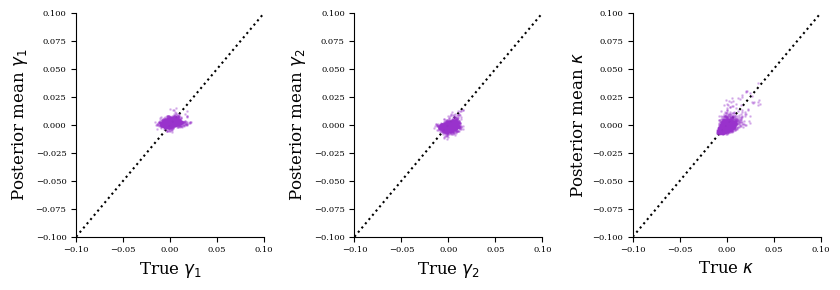

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(8.5, 3))
b = 0

_ = ax[0].scatter(shear1_true[...,b].flatten().cpu(), shear1_pred[...,b].flatten().cpu(),
                  color = npe_color, alpha = alpha, s = s, zorder = 1)
_ = ax[0].set_xlabel(r'True $\gamma_1$', fontsize = fontsize)
_ = ax[0].set_ylabel(r'Posterior mean $\gamma_1$', fontsize = fontsize)
_ = ax[0].tick_params(axis='both', which='major', labelsize=ticklabelsize)
_ = ax[0].set_xlim((axmin, axmax))
_ = ax[0].set_ylim((axmin, axmax))
_ = ax[0].axline((0,0), slope = 1, linestyle = ':', color = 'black', zorder = 0)

_ = ax[1].scatter(shear2_true[...,b].flatten().cpu(), shear2_pred[...,b].flatten().cpu(),
                  color = npe_color, alpha = alpha, s = s, zorder = 1)
_ = ax[1].set_xlabel(r'True $\gamma_2$', fontsize = fontsize)
_ = ax[1].set_ylabel(r'Posterior mean $\gamma_2$', fontsize = fontsize)
_ = ax[1].tick_params(axis='both', which='major', labelsize=ticklabelsize)
_ = ax[1].set_xlim((axmin, axmax))
_ = ax[1].set_ylim((axmin, axmax))
_ = ax[1].axline((0,0), slope = 1, linestyle = ':', color = 'black', zorder = 0)

_ = ax[2].scatter(convergence_true[...,b].flatten().cpu(), convergence_pred[...,b].flatten().cpu(),
                  color = npe_color, alpha = alpha, s = s, zorder = 1)
_ = ax[2].set_xlabel(r'True $\kappa$', fontsize = fontsize)
_ = ax[2].set_ylabel(r'Posterior mean $\kappa$', fontsize = fontsize)
_ = ax[2].tick_params(axis='both', which='major', labelsize=ticklabelsize)
_ = ax[2].set_xlim((axmin, axmax))
_ = ax[2].set_ylim((axmin, axmax))
_ = ax[2].axline((0,0), slope = 1, linestyle = ':', color = 'black', zorder = 0)

for a in ax.flat:
    _ = a.spines[['top', 'right']].set_visible(False)

fig.tight_layout()

fig.savefig(f"figures/scatterplots_bin{b+1}.png", dpi = 600, transparent = True, bbox_inches = 'tight', pad_inches = 0)

*Redshift bin 2:*

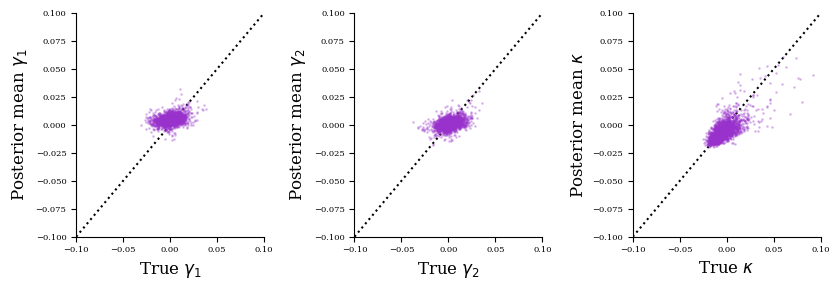

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(8.5, 3))
b = 1

_ = ax[0].scatter(shear1_true[...,b].flatten().cpu(), shear1_pred[...,b].flatten().cpu(),
                  color = npe_color, alpha = alpha, s = s, zorder = 1)
_ = ax[0].set_xlabel(r'True $\gamma_1$', fontsize = fontsize)
_ = ax[0].set_ylabel(r'Posterior mean $\gamma_1$', fontsize = fontsize)
_ = ax[0].tick_params(axis='both', which='major', labelsize=ticklabelsize)
_ = ax[0].set_xlim((axmin, axmax))
_ = ax[0].set_ylim((axmin, axmax))
_ = ax[0].axline((0,0), slope = 1, linestyle = ':', color = 'black', zorder = 0)

_ = ax[1].scatter(shear2_true[...,b].flatten().cpu(), shear2_pred[...,b].flatten().cpu(),
                  color = npe_color, alpha = alpha, s = s, zorder = 1)
_ = ax[1].set_xlabel(r'True $\gamma_2$', fontsize = fontsize)
_ = ax[1].set_ylabel(r'Posterior mean $\gamma_2$', fontsize = fontsize)
_ = ax[1].tick_params(axis='both', which='major', labelsize=ticklabelsize)
_ = ax[1].set_xlim((axmin, axmax))
_ = ax[1].set_ylim((axmin, axmax))
_ = ax[1].axline((0,0), slope = 1, linestyle = ':', color = 'black', zorder = 0)

_ = ax[2].scatter(convergence_true[...,b].flatten().cpu(), convergence_pred[...,b].flatten().cpu(),
                  color = npe_color, alpha = alpha, s = s, zorder = 1)
_ = ax[2].set_xlabel(r'True $\kappa$', fontsize = fontsize)
_ = ax[2].set_ylabel(r'Posterior mean $\kappa$', fontsize = fontsize)
_ = ax[2].tick_params(axis='both', which='major', labelsize=ticklabelsize)
_ = ax[2].set_xlim((axmin, axmax))
_ = ax[2].set_ylim((axmin, axmax))
_ = ax[2].axline((0,0), slope = 1, linestyle = ':', color = 'black', zorder = 0)

for a in ax.flat:
    _ = a.spines[['top', 'right']].set_visible(False)

fig.tight_layout()

fig.savefig(f"figures/scatterplots_bin{b+1}.png", dpi = 600, transparent = True, bbox_inches = 'tight', pad_inches = 0)

*Redshift bin 3:*

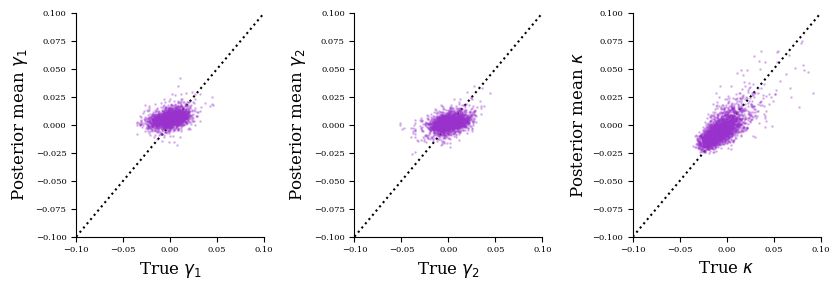

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(8.5, 3))
b = 2

_ = ax[0].scatter(shear1_true[...,b].flatten().cpu(), shear1_pred[...,b].flatten().cpu(),
                  color = npe_color, alpha = alpha, s = s, zorder = 1)
_ = ax[0].set_xlabel(r'True $\gamma_1$', fontsize = fontsize)
_ = ax[0].set_ylabel(r'Posterior mean $\gamma_1$', fontsize = fontsize)
_ = ax[0].tick_params(axis='both', which='major', labelsize=ticklabelsize)
_ = ax[0].set_xlim((axmin, axmax))
_ = ax[0].set_ylim((axmin, axmax))
_ = ax[0].axline((0,0), slope = 1, linestyle = ':', color = 'black', zorder = 0)

_ = ax[1].scatter(shear2_true[...,b].flatten().cpu(), shear2_pred[...,b].flatten().cpu(),
                  color = npe_color, alpha = alpha, s = s, zorder = 1)
_ = ax[1].set_xlabel(r'True $\gamma_2$', fontsize = fontsize)
_ = ax[1].set_ylabel(r'Posterior mean $\gamma_2$', fontsize = fontsize)
_ = ax[1].tick_params(axis='both', which='major', labelsize=ticklabelsize)
_ = ax[1].set_xlim((axmin, axmax))
_ = ax[1].set_ylim((axmin, axmax))
_ = ax[1].axline((0,0), slope = 1, linestyle = ':', color = 'black', zorder = 0)

_ = ax[2].scatter(convergence_true[...,b].flatten().cpu(), convergence_pred[...,b].flatten().cpu(),
                  color = npe_color, alpha = alpha, s = s, zorder = 1)
_ = ax[2].set_xlabel(r'True $\kappa$', fontsize = fontsize)
_ = ax[2].set_ylabel(r'Posterior mean $\kappa$', fontsize = fontsize)
_ = ax[2].tick_params(axis='both', which='major', labelsize=ticklabelsize)
_ = ax[2].set_xlim((axmin, axmax))
_ = ax[2].set_ylim((axmin, axmax))
_ = ax[2].axline((0,0), slope = 1, linestyle = ':', color = 'black', zorder = 0)

for a in ax.flat:
    _ = a.spines[['top', 'right']].set_visible(False)

fig.tight_layout()

fig.savefig(f"figures/scatterplots_bin{b+1}.png", dpi = 600, transparent = True, bbox_inches = 'tight', pad_inches = 0)

*Redshift bin 4:*

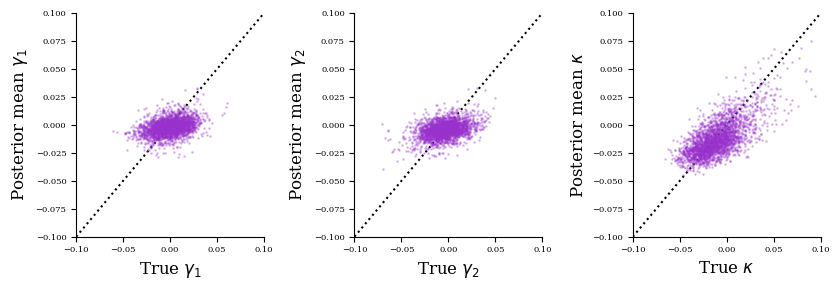

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(8.5, 3))
b = 3

_ = ax[0].scatter(shear1_true[...,b].flatten().cpu(), shear1_pred[...,b].flatten().cpu(),
                  color = npe_color, alpha = alpha, s = s, zorder = 1)
_ = ax[0].set_xlabel(r'True $\gamma_1$', fontsize = fontsize)
_ = ax[0].set_ylabel(r'Posterior mean $\gamma_1$', fontsize = fontsize)
_ = ax[0].tick_params(axis='both', which='major', labelsize=ticklabelsize)
_ = ax[0].set_xlim((axmin, axmax))
_ = ax[0].set_ylim((axmin, axmax))
_ = ax[0].axline((0,0), slope = 1, linestyle = ':', color = 'black', zorder = 0)

_ = ax[1].scatter(shear2_true[...,b].flatten().cpu(), shear2_pred[...,b].flatten().cpu(),
                  color = npe_color, alpha = alpha, s = s, zorder = 1)
_ = ax[1].set_xlabel(r'True $\gamma_2$', fontsize = fontsize)
_ = ax[1].set_ylabel(r'Posterior mean $\gamma_2$', fontsize = fontsize)
_ = ax[1].tick_params(axis='both', which='major', labelsize=ticklabelsize)
_ = ax[1].set_xlim((axmin, axmax))
_ = ax[1].set_ylim((axmin, axmax))
_ = ax[1].axline((0,0), slope = 1, linestyle = ':', color = 'black', zorder = 0)

_ = ax[2].scatter(convergence_true[...,b].flatten().cpu(), convergence_pred[...,b].flatten().cpu(),
                  color = npe_color, alpha = alpha, s = s, zorder = 1)
_ = ax[2].set_xlabel(r'True $\kappa$', fontsize = fontsize)
_ = ax[2].set_ylabel(r'Posterior mean $\kappa$', fontsize = fontsize)
_ = ax[2].tick_params(axis='both', which='major', labelsize=ticklabelsize)
_ = ax[2].set_xlim((axmin, axmax))
_ = ax[2].set_ylim((axmin, axmax))
_ = ax[2].axline((0,0), slope = 1, linestyle = ':', color = 'black', zorder = 0)

for a in ax.flat:
    _ = a.spines[['top', 'right']].set_visible(False)

fig.tight_layout()

fig.savefig(f"figures/scatterplots_bin{b+1}.png", dpi = 600, transparent = True, bbox_inches = 'tight', pad_inches = 0)

**Plot shear and convergence maps for the entire test set:**

In [16]:
ra_mean = ra.mean([1,2,3])
dec_mean = dec.mean([1,2,3])

dec_sort_idx = torch.argsort(dec_mean)

dec_bins = dec_sort_idx.view(8,5)

sorted_indices = torch.zeros_like(dec_bins)
for i in range(8):
    ra_in_row = ra_mean[dec_bins[i]]
    ra_sort_idx = torch.argsort(-ra_in_row)
    sorted_indices[i] = dec_bins[i][ra_sort_idx]

idx = sorted_indices.flatten()

In [17]:
ra_sorted = rearrange(ra[idx].view(8,5,num_tiles_per_side,num_tiles_per_side,num_bins), "h w nh nw b -> (h nh) (w nw) b")
dec_sorted = rearrange(dec[idx].view(8,5,num_tiles_per_side,num_tiles_per_side,num_bins), "h w nh nw b -> (h nh) (w nw) b")
shear1_true_sorted = rearrange(shear1_true[idx].view(8,5,num_tiles_per_side,num_tiles_per_side,num_bins), "h w nh nw b -> (h nh) (w nw) b")
shear1_pred_sorted = rearrange(shear1_pred[idx].view(8,5,num_tiles_per_side,num_tiles_per_side,num_bins), "h w nh nw b -> (h nh) (w nw) b")
shear1_pred_samples_sorted = rearrange(shear1_pred_samples[idx].view(8,5,num_tiles_per_side,num_tiles_per_side,num_bins,num_samples), "h w nh nw b ns -> (h nh) (w nw) b ns")
shear1_std_sorted = rearrange(shear1_std[idx].view(8,5,num_tiles_per_side,num_tiles_per_side,num_bins), "h w nh nw b -> (h nh) (w nw) b")
shear2_true_sorted = rearrange(shear2_true[idx].view(8,5,num_tiles_per_side,num_tiles_per_side,num_bins), "h w nh nw b -> (h nh) (w nw) b")
shear2_pred_sorted = rearrange(shear2_pred[idx].view(8,5,num_tiles_per_side,num_tiles_per_side,num_bins), "h w nh nw b -> (h nh) (w nw) b")
shear2_pred_samples_sorted = rearrange(shear2_pred_samples[idx].view(8,5,num_tiles_per_side,num_tiles_per_side,num_bins,num_samples), "h w nh nw b ns -> (h nh) (w nw) b ns")
shear2_std_sorted = rearrange(shear2_std[idx].view(8,5,num_tiles_per_side,num_tiles_per_side,num_bins), "h w nh nw b -> (h nh) (w nw) b")
convergence_true_sorted = rearrange(convergence_true[idx].view(8,5,num_tiles_per_side,num_tiles_per_side,num_bins), "h w nh nw b -> (h nh) (w nw) b")
convergence_pred_sorted = rearrange(convergence_pred[idx].view(8,5,num_tiles_per_side,num_tiles_per_side,num_bins), "h w nh nw b -> (h nh) (w nw) b")
convergence_pred_samples_sorted = rearrange(convergence_pred_samples[idx].view(8,5,num_tiles_per_side,num_tiles_per_side,num_bins,num_samples), "h w nh nw b ns -> (h nh) (w nw) b ns")
convergence_std_sorted = rearrange(convergence_std[idx].view(8,5,num_tiles_per_side,num_tiles_per_side,num_bins), "h w nh nw b -> (h nh) (w nw) b")

In [18]:
interpolation = 'none'

extent = [ra_sorted.max().cpu(), ra_sorted.min().cpu(),
          dec_sorted.min().cpu(), dec_sorted.max().cpu()]

*Convergence:*

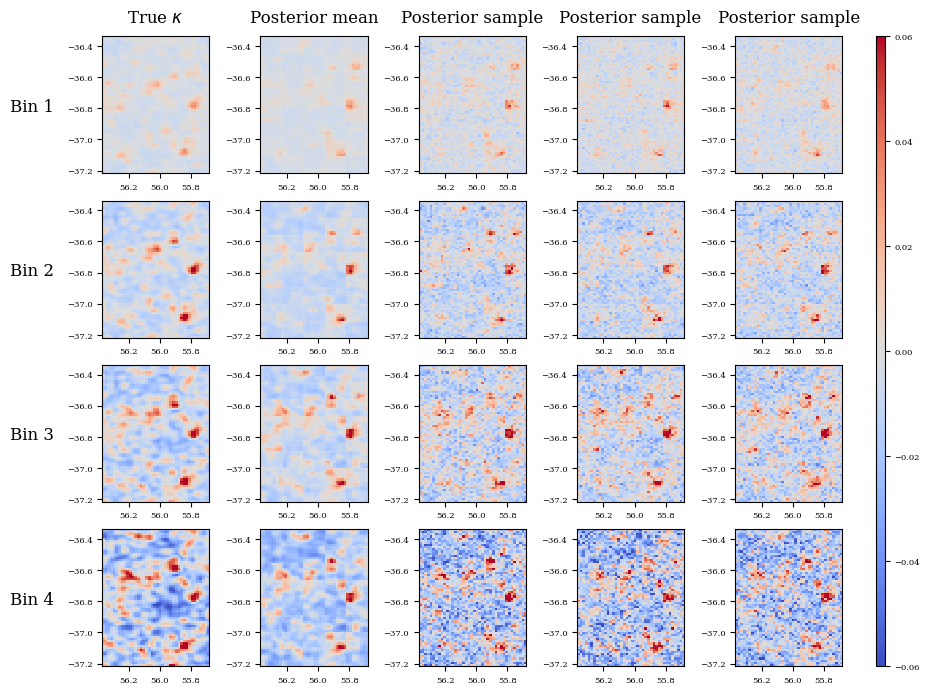

In [19]:
fig, ax = plt.subplots(4, 5, figsize = (8.5, 7))
fontsize = 12
ticklabelsize = 6
vmin = -0.06
vmax = 0.06

for b in range(4):
    # True
    _ = ax[b,0].imshow(convergence_true_sorted[...,b].cpu(), extent = extent, origin = 'lower',
                    interpolation = interpolation, vmin = vmin, vmax = vmax, cmap = 'coolwarm')

    # Posterior mean
    _ = ax[b,1].imshow(convergence_pred_sorted[...,b].cpu(), extent = extent, origin = 'lower',
                       interpolation = interpolation, vmin = vmin, vmax = vmax, cmap = 'coolwarm')
    
    # Sample 1
    _ = ax[b,2].imshow(convergence_pred_samples_sorted[...,b,0].cpu(), extent = extent, origin = 'lower',
                       interpolation = interpolation, vmin = vmin, vmax = vmax, cmap = 'coolwarm')
    
    # Sample 2
    _ = ax[b,3].imshow(convergence_pred_samples_sorted[...,b,1].cpu(), extent = extent, origin = 'lower',
                       interpolation = interpolation, vmin = vmin, vmax = vmax, cmap = 'coolwarm')
    
    # Sample 3
    tmp = ax[b,4].imshow(convergence_pred_samples_sorted[...,b,2].cpu(), extent = extent, origin = 'lower',
                         interpolation = interpolation, vmin = vmin, vmax = vmax, cmap = 'coolwarm')

_ = ax[0,0].set_title('True $\kappa$', fontsize = fontsize, pad = 10)
_ = ax[0,1].set_title('Posterior mean', fontsize = fontsize, pad = 10)
_ = ax[0,2].set_title('Posterior sample', fontsize = fontsize, pad = 10)
_ = ax[0,3].set_title('Posterior sample', fontsize = fontsize, pad = 10)
_ = ax[0,4].set_title('Posterior sample', fontsize = fontsize, pad = 10)
_ = ax[0,0].set_ylabel('Bin 1', fontsize = fontsize, rotation = 0, labelpad = 25, y = 0.425)
_ = ax[1,0].set_ylabel('Bin 2', fontsize = fontsize, rotation = 0, labelpad = 25, y = 0.425)
_ = ax[2,0].set_ylabel('Bin 3', fontsize = fontsize, rotation = 0, labelpad = 25, y = 0.425)
_ = ax[3,0].set_ylabel('Bin 4', fontsize = fontsize, rotation = 0, labelpad = 25, y = 0.425)

fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.975, 0.05, 0.01, 0.9])
cbar_ax.tick_params(labelsize = ticklabelsize)
fig.colorbar(tmp, cax=cbar_ax)

fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)

for a in ax.flat:
    a.tick_params(axis='both', which='major', labelsize=ticklabelsize)

fig.savefig("figures/posteriormeanconvergencemaps.png", dpi = 600, transparent = True, bbox_inches = 'tight', pad_inches = 0)

*Shear:*

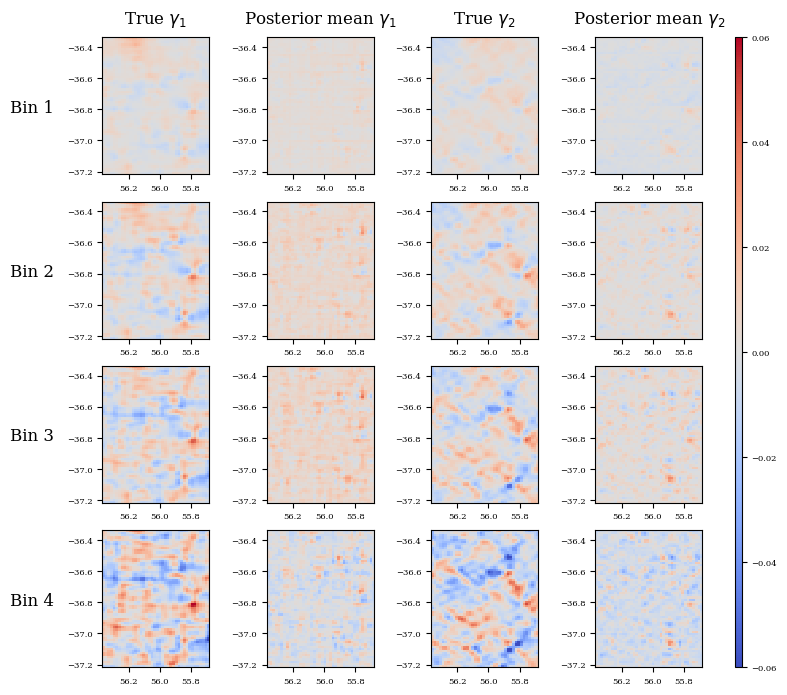

In [20]:
fig, ax = plt.subplots(4, 4, figsize = (7, 7))
fontsize = 12
ticklabelsize = 6
vmin = -0.06
vmax = 0.06

for b in range(4):
    # True shear 1
    _ = ax[b,0].imshow(shear1_true_sorted[...,b].cpu(), extent = extent, origin = 'lower',
                    interpolation = interpolation, vmin = vmin, vmax = vmax, cmap = 'coolwarm')

    # Posterior mean shear 1
    _ = ax[b,1].imshow(shear1_pred_sorted[...,b].cpu(), extent = extent, origin = 'lower',
                       interpolation = interpolation, vmin = vmin, vmax = vmax, cmap = 'coolwarm')
    
    # True shear 2
    _ = ax[b,2].imshow(shear2_true_sorted[...,b].cpu(), extent = extent, origin = 'lower',
                       interpolation = interpolation, vmin = vmin, vmax = vmax, cmap = 'coolwarm')
    
    # Posterior mean shear 2
    tmp = ax[b,3].imshow(shear2_pred_sorted[...,b].cpu(), extent = extent, origin = 'lower',
                       interpolation = interpolation, vmin = vmin, vmax = vmax, cmap = 'coolwarm')

_ = ax[0,0].set_title('True $\gamma_1$', fontsize = fontsize, pad = 10)
_ = ax[0,1].set_title('Posterior mean $\gamma_1$', fontsize = fontsize, pad = 10)
_ = ax[0,2].set_title('True $\gamma_2$', fontsize = fontsize, pad = 10)
_ = ax[0,3].set_title('Posterior mean $\gamma_2$', fontsize = fontsize, pad = 10)
_ = ax[0,0].set_ylabel('Bin 1', fontsize = fontsize, rotation = 0, labelpad = 25, y = 0.425)
_ = ax[1,0].set_ylabel('Bin 2', fontsize = fontsize, rotation = 0, labelpad = 25, y = 0.425)
_ = ax[2,0].set_ylabel('Bin 3', fontsize = fontsize, rotation = 0, labelpad = 25, y = 0.425)
_ = ax[3,0].set_ylabel('Bin 4', fontsize = fontsize, rotation = 0, labelpad = 25, y = 0.425)

fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.975, 0.05, 0.01, 0.9])
cbar_ax.tick_params(labelsize = ticklabelsize)
fig.colorbar(tmp, cax=cbar_ax)

fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)

for a in ax.flat:
    a.tick_params(axis='both', which='major', labelsize=ticklabelsize)

fig.savefig("figures/posteriormeanshearmaps.png", dpi = 600, transparent = True, bbox_inches = 'tight', pad_inches = 0)

*Posterior standard deviations:*

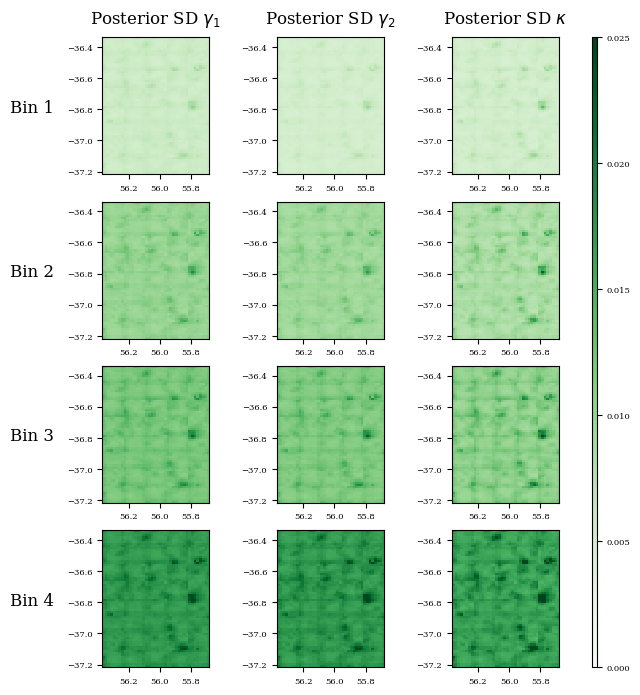

In [21]:
fig, ax = plt.subplots(4, 3, figsize = (5.5, 7))
fontsize = 12
ticklabelsize = 6
vmin = 0.0
vmax = 0.025
cmap = 'Greens'

for b in range(4):
    # Shear 1 std
    _ = ax[b,0].imshow(shear1_std_sorted[...,b].cpu(), extent = extent, origin = 'lower',
                    interpolation = interpolation, vmin = vmin, vmax = vmax, cmap = cmap)

    # Shear 2 std
    _ = ax[b,1].imshow(shear2_std_sorted[...,b].cpu(), extent = extent, origin = 'lower',
                       interpolation = interpolation, vmin = vmin, vmax = vmax, cmap = cmap)

    # Convergence std
    tmp = ax[b,2].imshow(convergence_std_sorted[...,b].cpu(), extent = extent, origin = 'lower',
                       interpolation = interpolation, vmin = vmin, vmax = vmax, cmap = cmap)

_ = ax[0,0].set_title('Posterior SD $\gamma_1$', fontsize = fontsize, pad = 10)
_ = ax[0,1].set_title('Posterior SD $\gamma_2$', fontsize = fontsize, pad = 10)
_ = ax[0,2].set_title('Posterior SD $\kappa$', fontsize = fontsize, pad = 10)
_ = ax[0,0].set_ylabel('Bin 1', fontsize = fontsize, rotation = 0, labelpad = 25, y = 0.425)
_ = ax[1,0].set_ylabel('Bin 2', fontsize = fontsize, rotation = 0, labelpad = 25, y = 0.425)
_ = ax[2,0].set_ylabel('Bin 3', fontsize = fontsize, rotation = 0, labelpad = 25, y = 0.425)
_ = ax[3,0].set_ylabel('Bin 4', fontsize = fontsize, rotation = 0, labelpad = 25, y = 0.425)

fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.975, 0.05, 0.01, 0.9])
cbar_ax.tick_params(labelsize = ticklabelsize)
fig.colorbar(tmp, cax=cbar_ax)

fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)

for a in ax.flat:
    a.tick_params(axis='both', which='major', labelsize=ticklabelsize)

fig.savefig("figures/posteriorstdevmaps.png", dpi = 600, transparent = True, bbox_inches = 'tight', pad_inches = 0)